# Using RSP tools to simulate microlensing light curves at the image level

This tutorial is based on tutorials available at RSP, and code by Karen Nowogrodzki and Anibal Varela.
We thank everyone involved in producing the tutorials for the community!
(the RSP tutorials are accessible through RSP or at https://github.com/lsst/tutorial-notebooks) 

## Microlensing phenomenon
When a compact object passes close to the line of sight to a distant light source, its gravitational field bends the source’s light, producing **magnification of the source brightness**. In general this phenomenon is achromatic and does not change the source color. The **characteristic light curve** depends on the properties of the lens, the relative motion of the source and the lens, and the geometry of the event.
  

#### Microlensing event parameters
Microlensing depends on the lens and source properties, the geometry and their relative motion. These define the physical configuration of the lens–source system:

- **Relative distances**: observer–lens–source geometry ($D_{LS}$, $D_{L}$, $D_{S}$)
- **Proper motion** ($ \mu_{rel} $): relative transverse motion between lens and source as seen by the observer
- **The lens mass distribution**: just $M$ for a point mass
- **Source radius**: relevant for finite-source effects
- **Impact parameter**: closest approach between lens and source
- **Blending**: extra flux from nearby unresolved stars

The **angular Einstein radius** sets the characteristic scale of the event:

$\theta_E = \sqrt{  \frac{4GM}{c^2} \frac{D_{LS}}{D_L D_S}  }$

## Paczyński Model: Microlensing equations 

The simplest and most commonly observed light-curve is given by a **point-source** lensed by a **point-lens** (PSPL) with a uniform relative proper motion between lens and source. In this case, the time-dependent separation between source and lens in units of $\theta_E$ is:

$
u(t) = \sqrt{ u_0^2 + \left( \frac{t - t_0}{t_E} \right)^2 },
$

where **$u_0$** is impact parameter (in units of Einstein radius), **$t_0$** is the time of closest approach, and 
$
t_E = \frac{\theta_E}{\mu_{rel}},
$
is the **Einstein time**, which sets the characteristic time-scale of the event and represents how long it takes the source-lens separation to change by one Einstein radius.

**Paczyński Magnification**: The total magnification for a point-source, point-lens is:

$
A(u) = \frac{u^2 + 2}{u \sqrt{u^2 + 4}}.
$

Therefore, the magnification as a function of time for a PSPL event with uniform motion is given by $A(u(t))$, so that the flux as a function of time (light-curve) is simply

$
F(t) = F_s \, A(u(t))
$

For a more realistic light-curve, one need to include a contamination of the flux from other sources (including unresolved nearby stars and, possibly, the flux from the lens star).
In this case, the light curve will be given by

$
F(t) = F_s \, A(u(t)) + F_b,
$

where:
- **$F_s$** – source flux  
- **$F_b$** – blended flux contribution

Einstein radius (mas): 0.985
Einstein timescale (days): 179.8


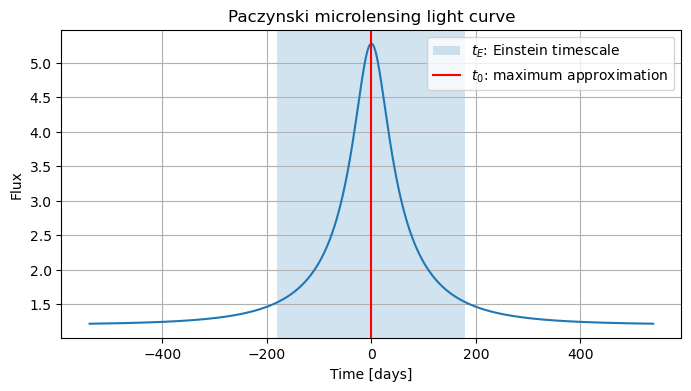

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

# Set microlensing system parameters

lens_mass = 5        # lens mass in solar masses
mu_rel = 2.0           # relative proper motion (mas/yr)
D_L = 6.0e3            # lens distance in pc
D_S = 7.0e3            # source distance in pc
t0 = 0.0               # time of maximum approximation [days]
u0 = 0.2               # minimum impact parameter
F_s = 1.0              # source flux (arbitrary units)
F_b = 0.2              # blend flux

# Convert system parameters into light-curve parameters, using the appropriate physical units

def einstein_angular_radius(M_L, D_L, D_S):
    """
    Inputs:
        M_L: (float) mass in solar masses
        D_L: (float) lens distance in pc
        D_S: (float) source distance in pc

    Returns: (float) theta_E in mas 
    """
    D_L = D_L * u.pc
    D_S = D_S * u.pc
    M_L = M_L * u.M_sun
    C = const.c
    G = const.G
    K = 4 * G / (C**2)
    pi_rel = ((1 / D_L) - (1 / D_S)) * u.rad # relative parallax

    theta_E_rad = np.sqrt(K * pi_rel * M_L)
    return theta_E_rad.to(u.mas, equivalencies=u.dimensionless_angles()).value


def einstein_timescale(theta_E, mu_rel):
    """
    Inputs: 
        theta_E: (float) Einstein radius in mas
        mu_rel: (float) proper motion in mas/year
    Returns: (float) t_E in days
    """
    mu_rel = mu_rel * (u.mas / u.year)
    return (theta_E*u.mas / mu_rel).to(u.day).value

theta_E = einstein_angular_radius(lens_mass, D_L, D_S)  # mas
t_E = einstein_timescale(theta_E, mu_rel)       # days

print(f"Einstein radius (mas): {theta_E:.3f}")
print(f"Einstein timescale (days): {t_E:.1f}")

def magnification(u):
    """Paczynski magnification for a point-source, point-lens."""
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

def microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b):
    """Return total flux F(t) = F_s * A(u) + F_b."""
    u = np.sqrt(u0**2 + ((t - t0) / t_E)**2)
    A = magnification(u)
    return F_s * A + F_b

t = np.linspace(-3*t_E, 3*t_E, 500)
F_t = microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b)

plt.figure(figsize=(8,4))
plt.plot(t, F_t)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.axvspan(t0 - t_E, t0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.axvline(t0, color ="r", label="$t_0$: maximum approximation")
plt.title("Paczynski microlensing light curve")
plt.grid(True)
plt.legend()
plt.show()


## Image-Based Simulations

**Note on blending:**

When simulating directly the light-curve, the blend flux $F_b$ is added by hand to represent extra light from unresolved nearby stars. But when the microlensed source is **injected directly into real images** and then measured, the blending comes out **automatic** (i.e. self-consistently):

- The image already contains sky background and neighboring stars.  
- The measured flux naturally includes all local contamination.  

Thus, in this simulation we set $F_b = 0 \rightarrow F(t) = F_s\, A(u(t))$. To be able to study the blending contribution as a function of environment and other factors is precisely one of the motivations to preform the simulation on the images and recover the light-curve directly from them.



## Plan

We will go through a sequence of steps to understand the simulation of microlensing events on images using the `ulens_lsst` pipeline
1. **Sources**: generated by TRILEGAL for LSST, available through NOIRLab's AstroDataLab 
2. **Microlensing system parameters**: Genulens
3. **LSST cadence**: Get time-stamps to create the micronlensing light curve with realistic cadence (yet, without errors)
4. **Simulating light curves** with `pyLIMA` (high cadence, no noise)

5. **Simulate LSST-like microlensing light curve at image level**

6. Efficient generation of many light curves in a given region of the sky with **`ulens_lsst`**

## 1. Sources: LSST's stellar distribution
[TRILEGAL from NOIRLab AstroDataLab](https://datalab.noirlab.edu/data/lsst-sim):

The LSST SIM tables contain a large simulation, based on the TRILEGAL code, of the stars to be observed by the Vera C. Rubin Observatory Legacy Survey of Space and Time (LSST). TRILEGAL uses databases of stellar evolutionary tracks, synthetic spectra, and pulsation models, added to simple prescriptions for the stellar density and star formation histories of the main structures of the Galaxy, to generate mock stellar samples through a population synthesis approach.

LSST SIM provides tables containing a complete simulation for single stars in the Milky Way and Magellanic Clouds down to a depth of $r=27.5$ mag, equivalent to the co-added depth from the Wide-Fast-Deep portion of the LSST survey. LSST SIM also provides a table for a subset of the anticipated binary systems, including interacting ones, as derived with the BinaPSE module of TRILEGAL.


#### Install Data Lab

##### You will need to install Data Lab to query the TRILEGAL database. We recommend installing using the terminal, not from this notebook:
`pip install --upgrade astro-datalab`

#### Query Data Lab's datasets

Here is a function to create the query to retrieve the needed data.

In [14]:
from dl import queryClient as qc

def sky_catalog_query(catalog, columns, regions, conditions=None, language = "sql"):
    """
    Generate a query for astronomical catalogs based on spatial regions and filters.

    Parameters
    ----------
    catalog : str
        Name of the catalog table.
    columns : list of str
        List of column names to select.
    region : tuple
        (ra, dec, radius) in degrees.
    conditions : list of str
        List of additional filter conditions (e.g., 'mag < 20').
    language : str, optional
        Query language: 'sql' (uses q3c_radial_query) or 'adql' (uses CONTAINS + CIRCLE) (default: 'sql').
    """
    ra, dec, radius = region
    if language == "sql":
        # SQL version with q3c_radial_query
        spatial_clause = f"q3c_radial_query(ra, dec, {ra}, {dec}, {radius})"
    elif language == "adql":
        # ADQL version with CONTAINS + CIRCLE
        spatial_clause = f"CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius}))=1"
    else:
        raise ValueError("language must be 'sql' or 'adql'")

    # Additional conditions
    if conditions is not None:
        filter_part = " AND ".join(conditions)
    if conditions and spatial_clause:
        where_statement = f"({spatial_part}) AND ({filter_part})"
    elif spatial_clause:
        where_statement = spatial_clause
    elif conditions:
        where_statement = filter_part
    else:
        where_statement = "1=1"

    query = f"""
    SELECT {', '.join(columns)}
    FROM {catalog}
    WHERE {where_statement}
    """
    return query

We will query all sources within a radius of 0.5 degrees centered on (62,-34) and retrieve the columns of interest 
(for more details about this dataset columns, check this [NOIRLab page](https://datalab.noirlab.edu/data-explorer?showTable=lsst_sim.simdr2))

In [15]:
catalog = "lsst_sim.simdr2" # "lsst_sim.simdr2_binary"
region = (62, -34, 0.5) # degrees
columns = ["ra", "dec", "logl", "logte", 
           "umag", "gmag", "rmag", "imag", "zmag", "ymag", "gc", "label"]
# condition = 
query = sky_catalog_query(catalog, columns, region,  language="sql")
print(query)
try:
    res = qc.query(sql=query, fmt="table")
    sources = res.to_pandas()
except Exception as e:
    print(str(e))

# a quick look to the retrieved table:
sources


    SELECT ra, dec, logl, logte, umag, gmag, rmag, imag, zmag, ymag, gc, label
    FROM lsst_sim.simdr2
    WHERE q3c_radial_query(ra, dec, 62, -34, 0.5)
    


,ra,dec,logl,logte,umag,gmag,rmag,imag,zmag,ymag,gc,label
0,61.623969,-34.390371,-2.277,3.5828,31.061,28.505,27.199,26.631,26.354,26.205,3,1
1,61.601897,-34.375096,-0.378,3.7581,23.720,22.821,22.425,22.280,22.236,22.225,3,1
2,61.600147,-34.367165,-1.742,3.6344,30.052,28.153,27.232,26.831,26.638,26.534,3,1
3,61.598361,-34.365108,-2.135,3.5312,28.739,25.816,24.401,23.393,22.906,22.687,2,1
4,61.605346,-34.368540,-1.049,3.6648,27.603,25.804,25.010,24.693,24.548,24.464,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
20552,62.327281,-33.584432,-0.697,3.7139,28.755,27.502,26.939,26.717,26.628,26.585,3,1
20553,62.327096,-33.583170,-0.271,3.7656,28.014,27.080,26.700,26.570,26.536,26.527,3,1
20554,62.331486,-33.584130,-1.311,3.6616,27.631,26.016,25.234,24.893,24.735,24.653,3,1
20555,62.350772,-33.597834,-0.332,3.7666,25.675,24.859,24.495,24.360,24.320,24.312,3,1


#### Visualize the stellar distribution

To visualize source properties as a function of their position on the sky, set "column" variable to the name of the property of interest.

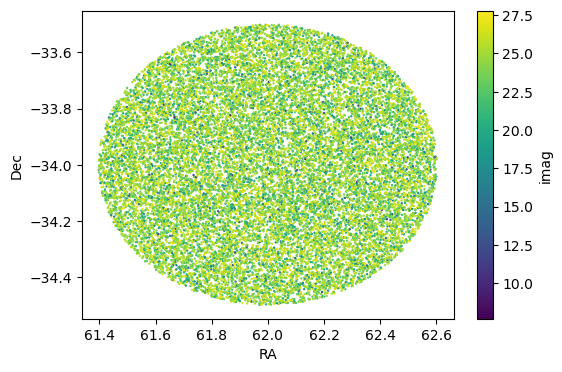

In [16]:
# choosing i_band magnitude
column = "imag"

plt.figure(figsize=(6,4))
sc = plt.scatter(
    sources["ra"],
    sources["dec"],
    s=0.5,
    c=sources[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


We can look at other properties of the stars provided by TRILEGAL, such as:
* "gc": Galactic component, thin disk=1, thick disk=2, halo=3, bulge=4, MCs=5
* "label": Evolutionary phase, PMS=0, MS=1, SGB=2, RGB=3, CHeB=4,5,6, EAGB=7, TPAGB=8, PAGB+WD=9

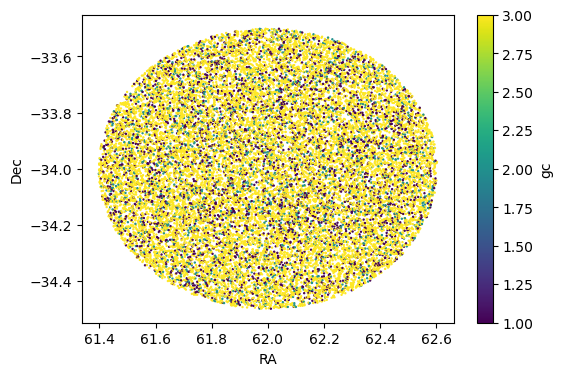

In [17]:
column = "gc"

plt.figure(figsize=(6,4))
sc = plt.scatter(
    sources["ra"],
    sources["dec"],
    s=0.5,
    c=sources[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


## 2. Microlensing system parameters: Genulens

**Genulens**: Microlensing event distribution simulator

Genulens is a Monte-Carlo tool that generates large samples of **artificial microlensing events** toward the Galactic bulge.  
It uses the Galactic model from **Koshimoto, Baba & Bennett (2021)** and is optimized for fields with  |l| < 10° and |b| < 7°.

Each **row in the Genulens output** corresponds to one possible microlensing event and includes:
- Einstein timescale `t_E`
- Angular Einstein radius `θ_E`
- Microlens parallax vector components
- Lens and source distances
- Proper motions
- Population flags (disk, bulge, NSD)
- A probability weight `wtj` for that event


### Usage

- Generate a distrbution of microlensing parameters for each sky position in Galactic coordinates, e.g.:
   ```bash
   ./genulens Nsimu 2e5 l 0.0 b -0.0
- In this notebook we will use a data set already generated for the bulge center within the recommended coordinate limits. |l| < 10° and |b| < 7°.
The ready data set can be download from [this link](https://github.com/nowokaren/ulens_lsst/blob/main/data/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv) 

In [18]:
import pandas as pd
# set the following as the path to the ready Genlens dataset.
genulens_file_path = "Genulens_chunk_1.csv"
ulens_systems = pd.read_csv(genulens_file_path)

In [19]:
ulens_systems

,wtj,M_L,D_L,D_S,tE,thetaE,piE,piEN,piEE,mu_rel,muSl,muSb,i_L,iS,iL,fREM
0,0.074795,0.654286,3490,5443,80.256400,0.740064,0.138889,0.090923,0.104992,3.368060,-3.070350,-0.904281,99.0,5,6,0
1,0.263890,0.202545,4581,7715,20.187840,0.382484,0.231878,0.201122,0.115401,6.920123,-10.857400,-1.582570,99.0,8,5,0
2,0.087598,0.063387,2758,6055,12.114240,0.319285,0.618506,0.145912,-0.601049,9.626590,-7.132600,-1.007570,99.0,8,7,0
3,0.185654,0.638739,6834,7359,13.420190,0.233110,0.044813,-0.028811,-0.034324,6.344430,-0.918042,-1.961040,99.0,8,8,0
4,0.168014,0.187773,7332,7353,0.924588,0.024819,0.016230,0.007847,0.014207,9.804669,-9.930460,0.936496,99.0,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.176847,0.182997,5805,7418,16.047250,0.236304,0.158561,-0.049967,0.150482,5.378501,-5.304220,4.709800,99.0,8,8,0
9996,0.328649,0.551260,7176,7830,24.725300,0.228641,0.050929,-0.050839,0.003031,3.377552,-7.547400,-1.385860,99.0,8,8,0
9997,0.328649,0.116017,5291,7840,18.444030,0.240937,0.255004,0.176783,0.183780,4.771309,-7.380180,2.371210,99.0,8,4,0
9998,0.253492,0.287910,7357,7687,5.139560,0.116918,0.049865,0.049811,-0.002307,8.308941,-9.038590,-5.324530,99.0,8,8,0


As we can see from the table above, `genulens` provides all the microlensing parameters needed to generate light-curves (for the PSPL model). However, in some cases, we may want to choose the lens mass $M_L$ by hand. In this case, we can compute $t_E$ using the expression given at the start of this notebook, such that we will only need $D_L$, $D_S$ and $\mu_{rel}$ from this table. 

**Note: Weights** `wtj`:
* If you are interested in generating a realistic distribution of microlensing events, you need to random sample the data set taking into account the weights.
* If you just need to generate a realistic microlensing light-curve and want to sample the possible range of parameters, you can just sample uniformly events from the data set.

In this tutorial we are going to do the second option.

## 3. LSST cadence (time-stamps)

The cadence is set by exposures present in the Data Preview choosen for the simulation. In this example we are going to use [**DP0.2**](https://dp0-2.lsst.io/data-products-dp0-2/index.html#) images. 

https://dp0-2.lsst.io/data-products-dp0-2/index.html#

### Load individual exposures that overlap with the region where we will simulate the microlensing events
First, we need to collect exposure `dataIds` for those calibrated exposures (`calexp`) overlapping with the region of interest.

In [22]:
from lsst.daf.butler import Butler
butler = Butler('dp02', collections='2.2i/runs/DP0.2')

Defining the region of interest (where we want to inject microlensing events) and the bands 

In [23]:
bands = "ugrizy"
bands_str = f"({', '.join(map(repr, bands))})"
ra, dec, radius = 62, -34, 0.5

Query to get all `calexps` that intercept the region of interest in all bands

In [24]:
from lsst.sphgeom import Region
circle = Region.from_ivoa_pos(f"CIRCLE {ra} {dec} {radius}")
n_max = None
datasetRefs = list(
    butler.query_datasets(
        "calexp",
        where=f"visit_detector_region.region OVERLAPS my_region AND band IN {bands_str}",
        bind={"ra": ra, "dec": dec, "my_region": circle},
        limit=None if n_max is None else n_max,
    )
)
print(f"Found {len(datasetRefs)} calexps.")

Found 11130 calexps.


In [25]:
# This object contains information in every calexp
datasetRefs[:2]

[DatasetRef(DatasetType('calexp', {band, instrument, detector, physical_filter, visit_system, visit}, ExposureF), {instrument: 'LSSTCam-imSim', detector: 0, visit: 169764, band: 'y', physical_filter: 'y_sim_1.4', visit_system: 1}, run='2.2i/runs/DP0.2/v23_0_0_rc5/PREOPS-905/20211218T002844Z', id=bd7a2e2b-81dc-492a-aa02-4e51aa6a47ce),
 DatasetRef(DatasetType('calexp', {band, instrument, detector, physical_filter, visit_system, visit}, ExposureF), {instrument: 'LSSTCam-imSim', detector: 0, visit: 189315, band: 'y', physical_filter: 'y_sim_1.4', visit_system: 1}, run='2.2i/runs/DP0.2/v23_0_0_rc5/PREOPS-905/20211218T002844Z', id=c7c36878-b666-4151-b4a1-d41d5fd17b35)]

### Load exposure midpoint time (MJD) 
The next step is to load epochs (i.e. time-stamps) for each visit on the region of interest (given in terms of Modified Julian Day, MJD)

Notice that this information is not contained in `datasetRefs` directly and loading the entire calexp is inefficient in terms of memory and time. Therefore, we need to query the `CcdVisit` table to get the time-stamps for each visit.

**Note**: The ccd visits search uses the location of the center of the CCD. However we are interested in all CcdVisits that intersect our region, even if the center is not contained there. Therefore we increase the search radius by half of CCD size, to make sure we find all CcdVisits that intersect our region (we could have used half the diagonal). 
With this criterion, some CcdVisits will not overlap with the region. Therefore, the output dataset for this search will be larger than the number of calexps found for the region to be injected (in the cell above).


In [26]:
from lsst.rsp import get_tap_service
import os

calexps_data = []
catalog = "CcdVisit"
columns = ["ra", "decl", "expMidptMJD", "detector", "visitId", "psfSigma", "zeroPoint"]
full_catalog = f"dp02_dc2_catalogs.{catalog}"
delta_radius = 0.2    # Since CcdVisit coords (ra, decl) are the center of each exposure (CCD), 
# we need to query ccd_visits overlapping re region of interest plus at leas the diagonal of a 
# calexp angular distance to retrieve all calexps

query = f"""
SELECT {', '.join(columns)}
FROM {full_catalog}
WHERE CONTAINS(
        POINT('ICRS', ra, decl),
        CIRCLE('ICRS', {ra}, {dec}, {radius+delta_radius})
      ) = 1
"""

service = get_tap_service("tap")
job = service.submit_job(query)
job.run()
job.wait(phases=["COMPLETED", "ERROR"])

if job.phase == "ERROR":
    job.raise_if_error()

ccd_visit = job.fetch_result().to_table().to_pandas()

print(f"Records found: {len(ccd_visit)}")

Records found: 12740


In [27]:
# we can take a quick look at the information for each individual exposure we have collected
ccd_visit

,ra,decl,expMidptMJD,detector,visitId,psfSigma,zeroPoint
0,62.053270,-34.654634,60962.274795,117,944220,1.86489,32.334499
1,61.972995,-34.429801,60962.274795,120,944220,1.86519,32.334702
2,61.699853,-34.495316,60962.274795,121,944220,1.86628,32.334301
3,61.892295,-34.205009,60962.274795,123,944220,1.86034,32.335201
4,61.620104,-34.270134,60962.274795,124,944220,1.86555,32.334499
...,...,...,...,...,...,...,...
12735,61.826940,-33.340021,60336.070272,123,516370,3.01219,31.424700
12736,62.269802,-33.375145,61010.045486,0,971097,2.00119,31.458200
12737,61.419947,-33.492985,60631.239244,169,712575,2.29171,31.448999
12738,61.691308,-33.434031,60631.239244,170,712575,2.28876,31.449800


### Merge exposure Ids with epochs
With `calexps` refrences (`dataId`) we can filter its CCD visit data and save the `expMidptMJD`

In [28]:
calexps_data = []
for ref in datasetRefs:
    detector = ref.dataId["detector"]
    visit = ref.dataId["visit"]
    mask = (ccd_visit["detector"] == detector) & (ccd_visit["visitId"] == visit)
    if mask.any():
        row = ccd_visit[mask].iloc[0] # extract 0 row with iloc
        data = {
            "detector": detector,
            "visit": visit,
            "band": ref.dataId["band"],
            "expMidptMJD": row["expMidptMJD"],
            "psfSigma": row["psfSigma"],
        }
        calexps_data.append(data)


In [29]:
calexps_data = pd.DataFrame(calexps_data).sort_values("expMidptMJD")
calexps_data

,detector,visit,band,expMidptMJD,psfSigma
1294,23,2334,u,59583.120963,2.00700
1455,26,2334,u,59583.120963,1.99299
1124,20,2334,u,59583.120963,1.99418
1240,22,2334,u,59583.120963,1.99693
1067,19,2334,u,59583.120963,1.99537
...,...,...,...,...,...
1179,20,1233922,r,61404.157167,1.67791
841,14,1233922,r,61404.157167,1.67529
1340,23,1233922,r,61404.157167,1.67348
1293,22,1233922,r,61404.157167,1.67692


Lets plot the first 6 calexps that overlap with the chosen region

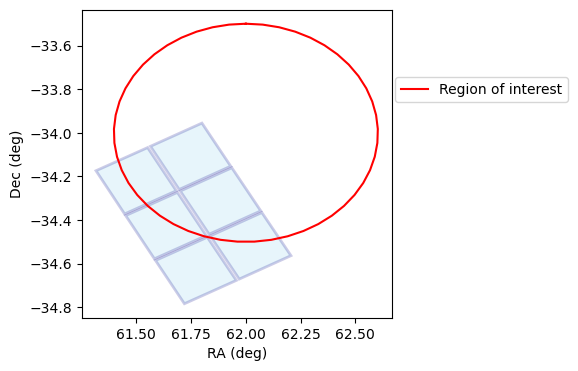

In [28]:
from astropy.coordinates import SkyCoord
import lsst.geom as geom 
fig, ax = plt.subplots(figsize=(4,4))
for i, calexp_data in calexps_data.head(6).iterrows():
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get("calexp", dataId=dataId)
    h, w = calexp.getDimensions()
    corners = [(calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getRa().asDegrees(),
                calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getDec().asDegrees())
               for x, y in [(0,0),(w,0),(w,h),(0,h)]]
    
    x, y = zip(*corners)
    ax.fill(x, y, facecolor="skyblue", alpha=0.2, edgecolor="darkblue", linewidth=2)

pa = np.linspace(0, 360, 50) * u.deg
circ = SkyCoord(ra*u.deg, dec*u.deg).directional_offset_by(pa, radius*u.deg)
ax.plot(circ.ra.deg, circ.dec.deg, c="r", label = "Region of interest")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend(loc=(1.01, 0.7))

**Note**: notice that a few `calexp` don't intersect the region as expected. The reason is that the region overlap query takes into account the padding area of the `calexp`. The `calexp` that don't have a true overlap will be ignored when running the injection and measurement task.

Now ploting the first 30 calexps that overlap

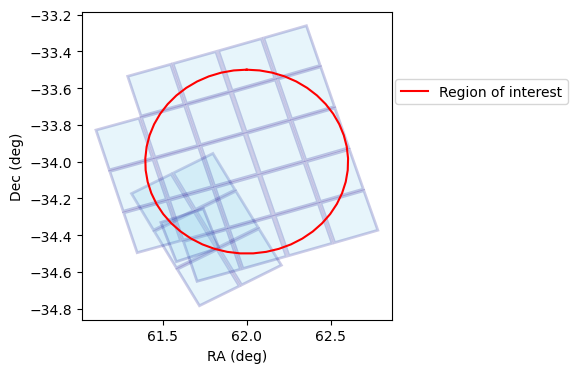

In [29]:
fig, ax = plt.subplots(figsize=(4,4))
for i, calexp_data in calexps_data.head(30).iterrows():
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get("calexp", dataId=dataId)
    h, w = calexp.getDimensions()
    corners = [(calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getRa().asDegrees(),
                calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getDec().asDegrees())
               for x, y in [(0,0),(w,0),(w,h),(0,h)]]
    
    x, y = zip(*corners)
    ax.fill(x, y, facecolor="skyblue", alpha=0.2, edgecolor="darkblue", linewidth=2)

pa = np.linspace(0, 360, 50) * u.deg
circ = SkyCoord(ra*u.deg, dec*u.deg).directional_offset_by(pa, radius*u.deg)
ax.plot(circ.ra.deg, circ.dec.deg, c="r", label = "Region of interest")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend(loc=(1.01, 0.7))


Plotting 50...

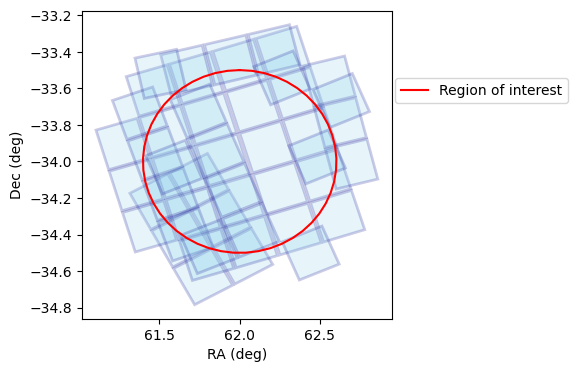

In [30]:
fig, ax = plt.subplots(figsize=(4,4))
for i, calexp_data in calexps_data.head(50).iterrows():
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get("calexp", dataId=dataId)
    h, w = calexp.getDimensions()
    corners = [(calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getRa().asDegrees(),
                calexp.getWcs().pixelToSky(geom.Point2D(x, y)).getDec().asDegrees())
               for x, y in [(0,0),(w,0),(w,h),(0,h)]]
    
    x, y = zip(*corners)
    ax.fill(x, y, facecolor="skyblue", alpha=0.2, edgecolor="darkblue", linewidth=2)

pa = np.linspace(0, 360, 50) * u.deg
circ = SkyCoord(ra*u.deg, dec*u.deg).directional_offset_by(pa, radius*u.deg)
ax.plot(circ.ra.deg, circ.dec.deg, c="r", label = "Region of interest")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend(loc=(1.01, 0.7))


Now we extract the MJD for each band, so that we can simulate the light-curve at each time-stamp corresponding to each band.

In [31]:
epochs_mjd = {
    band: sorted(set(calexps_data[calexps_data["band"] == band]["expMidptMJD"].values))
    for band in bands
}
epochs_mjd =  {k: v for k, v in epochs_mjd.items() if len(v) != 0} # clean from empty bands
epochs_mjd

{'u': [np.float64(59583.1209632),
  np.float64(59583.1227902),
  np.float64(59583.1232392),
  np.float64(59583.1241532),
  np.float64(59583.1246022),
  np.float64(59583.1269102),
  np.float64(59819.2927762),
  np.float64(59851.2166012),
  np.float64(59851.2170502),
  np.float64(59877.1229902),
  np.float64(59904.0762212),
  np.float64(59904.0866502),
  np.float64(59905.0642402),
  np.float64(59968.1013572),
  np.float64(60176.3987112),
  np.float64(60198.3260152),
  np.float64(60198.3264642),
  np.float64(60200.2545292),
  np.float64(60236.2286792),
  np.float64(60261.0759832),
  np.float64(60261.0907662),
  np.float64(60261.0925532),
  np.float64(60557.2637552),
  np.float64(60557.2642012),
  np.float64(60557.2686752),
  np.float64(60557.2704832),
  np.float64(60557.2781282),
  np.float64(60557.2835022),
  np.float64(60582.2175842),
  np.float64(60613.1367962),
  np.float64(60613.1470422),
  np.float64(60644.0694252),
  np.float64(60878.3984242),
  np.float64(60878.4012612),
  np.floa

## 4. Simulate microlensing high-cadece light curve with pyLIMA

[pyLIMA](https://github.com/ebachelet/pyLIMA) an open source and highly used software for modeling microlensing events

Un-comment the following line to install pyLIMA (or install directly on the terminal with `pip install pyLIMA`)

In [32]:
#!pip install pyLIMA

pyLIMA works with Julian Dates, so epochs needs to be transformed

In [33]:
epochs_jd = {band: np.array(epochs_mjd[band])+2400000.5 for band in epochs_mjd}
epochs_jd

{'u': array([2459583.6209632, 2459583.6227902, 2459583.6232392, 2459583.6241532,
        2459583.6246022, 2459583.6269102, 2459819.7927762, 2459851.7166012,
        2459851.7170502, 2459877.6229902, 2459904.5762212, 2459904.5866502,
        2459905.5642402, 2459968.6013572, 2460176.8987112, 2460198.8260152,
        2460198.8264642, 2460200.7545292, 2460236.7286792, 2460261.5759832,
        2460261.5907662, 2460261.5925532, 2460557.7637552, 2460557.7642012,
        2460557.7686752, 2460557.7704832, 2460557.7781282, 2460557.7835022,
        2460582.7175842, 2460613.6367962, 2460613.6470422, 2460644.5694252,
        2460878.8984242, 2460878.9012612, 2460878.9139852, 2460907.8980062,
        2460911.8146742, 2460911.8151232, 2460911.8169122, 2460911.8178122,
        2460966.6691772, 2460966.6696252, 2460970.6822402, 2460971.6292022,
        2460971.6735002, 2460996.5650892, 2460996.5922202, 2460996.6052982,
        2461297.7430672, 2461297.7695212, 2461297.7699702, 2461297.7708702,
       

In [34]:
# to compare Ideal high cadence light curve with Ideal LSST cadence light curve
survey_dates = (min(min(v) for v in epochs_jd.values()), max(max(v) for v in epochs_jd.values()) )
epochs_ideal = {band: np.linspace(survey_dates[0], survey_dates[1], 10000) for band in bands}

Define what is needed to run pyLIMA

In [35]:
import copy
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator

# pyLIMA simulates fluxes, so we need to provide a zero point to convert
ZP = {
    "u": 27.03,
    "g": 28.38,
    "r": 28.16,
    "i": 27.85,
    "z": 27.46,
    "y": 26.68
}

# assign a color to each filter, for plotting purposes
COLOR_FILTER = {
    "u": "b",
    "g": "c",
    "r": "g",
    "i": "orange",
    "z": "r",
    "y": "m"
}

# function to run pyLIMA
def simulate_microlensing(
    epochs: dict,          # Dict of np arrays: {band: times_JD}
    mags: dict,            # Dict: {band: baseline_mag}
    ra: float,             # Right ascension in degrees
    dec: float,            # Declination in degrees
    params: dict,          # Model params: {'t0': ..., 'u0': ..., 'tE': ..., optional 'piEN', 'piEE', etc.}
    model_type: str = 'PSPL',  # Model: 'PSPL', 'FSPL', 'USBL', etc.
    parallax: bool = False,    # Include parallax?
    g: float = 0.0,        # Blending factor
    event_name: str = 'ulens', # Event name
    event_id: int = 0      # Seed for random
):
    """
    Simulate microlensing light curve using pyLIMA.
    
    To switch models:
    - PSPL: Base params ('t0', 'u0', 'tE')
    - FSPL: Add 'rho'  (source radius in units of the Einstein radius)
    - USBL: Add 'rho', 's', 'q', 'alpha'
    - For parallax: Add 'piEN', 'piEE' (components of the parallax vector)
    - Extend by importing new model and adding elif block.
    
    Returns: (magnitudes dict, magnification dict)
    """
    # Create pyLIMA event
    my_event = event.Event(ra=ra, dec=dec)
    my_event.name = event_name
    
    # Add telescopes for each band
    bands = list(epochs.keys())
    for band in bands:
        # Dummy mag/err for simulation (will be overwritten)
        ts = np.column_stack((epochs[band], np.ones(len(epochs[band])) * 20, np.ones(len(epochs[band])) * 20)).astype(float)
        tel = telescopes.Telescope(
            name=band,
            camera_filter=band,
            location="Earth",
            lightcurve=ts,
            lightcurve_names=["time", "mag", "err_mag"],
            lightcurve_units=["JD", "mag", "mag"]
        )
        my_event.telescopes.append(tel)
    
    new_event = copy.deepcopy(my_event)
    np.random.seed(event_id)
    
    # Parallax setup
    parallax_model = ["Full", params['t0']] if parallax else ["None", 0.0]
    
    # Instantiate model 
    if model_type == 'PSPL':
        from pyLIMA.models import PSPL_model
        my_model = PSPL_model.PSPLmodel(new_event, parallax=parallax_model)
    elif model_type == 'FSPL':
        from pyLIMA.models import FSPLarge_model
        my_model = FSPLarge_model.FSPLargemodel(new_event, parallax=parallax_model)
    elif model_type == 'USBL':
        from pyLIMA.models import USBL_model
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        my_model = USBL_model.USBLmodel(new_event, origin=[choice, [0, 0]], 
                                        parallax=parallax_model, blend_flux_parameter="ftotal")
    else:
        raise ValueError(f"Unknown model: {model_type}")
    
    # Prepare parameters 
    model_params = {k: v for k, v in params.items() if (parallax or k not in ['piEN', 'piEE'])}
    my_parameters = list(model_params.values())
    
    # Add flux parameters for each telescope
    my_flux_parameters = []
    for telescope in new_event.telescopes:
        band = telescope.name
        flux_baseline = 10 ** ((ZP[band] - mags[band]) / 2.5)
        f_source = flux_baseline / (1 + g)
        f_total = f_source * (1 + g)
        # Adjust based on blend_flux_parameter (ftotal or g)
        if my_model.blend_flux_parameter == "ftotal":
            my_flux_parameters.extend([f_source, f_total])
        else:
            my_flux_parameters.extend([f_source, f_source * g])
    
    my_parameters += my_flux_parameters
    pyLIMA_params = my_model.compute_pyLIMA_parameters(my_parameters)
    
    # Simulate light curve without noise
    simulator.simulate_lightcurve(my_model, pyLIMA_params, add_noise=False)
    
    # Compute magnification and update light curves
    magnitudes = {}
    magnifications = {}
    for telescope in my_model.event.telescopes:
        mag = my_model.model_magnification(telescope, pyLIMA_params)
        flux = my_model.compute_the_microlensing_model(telescope, pyLIMA_params)["photometry"]
        telescope.lightcurve["magnification"] = mag
        telescope.lightcurve["flux"] = flux
        telescope.lightcurve["mag"] = ZP[telescope.name] - 2.5 * np.log10(np.abs(flux))
        magnitudes[telescope.name] = telescope.lightcurve["mag"].value
        magnifications[telescope.name] = mag
    
    return magnitudes, magnifications, pyLIMA_params

def einstein_angular_radius(M_L, D_L, D_S):
    """
    M_L: float [Msun]
    D_L, D_S: float [pc]
    Returns θ_E in mas
    """
    M_L = M_L * u.M_sun
    D_L = D_L * u.pc
    D_S = D_S * u.pc
    pi_rel = (1/D_L - 1/D_S) * u.rad  

    theta_E = np.sqrt( (4*const.G*M_L/const.c**2) * pi_rel )

    return theta_E.to(u.mas, equivalencies=u.dimensionless_angles()).value

def einstein_timescale(theta_E, mu_rel):
    """
    theta_E: mas
    mu_rel: mas/yr
    Returns t_E in days
    """
    theta_E = theta_E * u.mas
    mu_rel = mu_rel * (u.mas/u.yr)

    tE = (theta_E / mu_rel).to(u.day)
    return tE.value

# if we will account for finite sources
def norm_source_radius(logL, logTe, D_L, D_S, M_L):
    """
    Compute rho = theta_* / theta_E
    """
    # Stellar (source) physical radius
    L_star = (10**logL) * const.L_sun
    T_eff  = (10**logTe) * u.K

    R = np.sqrt(L_star / (4*np.pi*const.sigma_sb*T_eff**4))

    # Angular radius of the source
    theta_s = (R / (D_S * u.pc)).to(u.mas, equivalencies=u.dimensionless_angles())

    # Einstein radius 
    theta_E = einstein_angular_radius(M_L, D_L, D_S) * u.mas

    return (theta_s / theta_E).value

# for the case of binary lenses, s is the separation between the lens components in units of the Einstein radius
def norm_separation(D_L, semi_major_axis, theta_E):
    """
    D_L in pc, semi_major_axis in AU, θ_E in mas
    """
    D_L = D_L * u.pc
    a = semi_major_axis * u.au

    s_ang = (a/D_L).to(u.mas, equivalencies=u.dimensionless_angles())
    return (s_ang / (theta_E * u.mas)).value


#### Microlensing parameters 
Get the information of the microlensing events from the tables we generated from `genulens` (table `ulens_systems`) and from 
our query on AstroDataLab on TRILEGAL (table `sources`) to be used as inputs for pyLIMA.

In [36]:
name = "ulens"

src = sources.iloc[1241]  # arbitrarily choosing the soure 1241
ra = float(src["ra"])
dec = float(src["dec"])
logL = float(src["logl"])
logTe = float(src["logte"])

mags = {
    "u": float(src["umag"]),
    "g": float(src["gmag"]),
    "r": float(src["rmag"]),
    "i": float(src["imag"]),
    "z": float(src["zmag"]),
    "y": float(src["ymag"]),
}

lens = ulens_systems.iloc[3213]
M_L = float(lens["M_L"])     # Msun (if we were keeping the mass from genulens)
D_L = float(lens["D_L"])     # pc
D_S = float(lens["D_S"])     # pc
mu_rel = float(lens["mu_rel"])  # mas/yr
piEN = float(lens.get("piEN", 0.0))
piEE = float(lens.get("piEE", 0.0))


event_id = 0
g = 0.0  # No blending since it will come out naturally from the image-based simulation

Now, we can transform them to **pyLIMA parameters** (light curves parameters)

In [37]:
theta_E = einstein_angular_radius(M_L, D_L, D_S)   # mas
t_E     = einstein_timescale(theta_E, mu_rel)      # days
t_0     = np.median(epochs_jd["i"])                # the peak of the light curve
u0      = 0.01                                     # to ensure a high magnification event       

print("Microlensing Parameters")
print("-" * 40)
print(f"Einstein radius       θ_E  = {theta_E:>10.4f} mas")
print(f"Einstein timescale    t_E  = {t_E:>10.4f} days")
print(f"Event time            t_0  = {t_0:>10.4f} JD")
print(f"Impact parameter      u₀   = {u0:>10}")
print("-" * 40)


Microlensing Parameters
----------------------------------------
Einstein radius       θ_E  =     2.1950 mas
Einstein timescale    t_E  =   219.1926 days
Event time            t_0  = 2460597.7320 JD
Impact parameter      u₀   =       0.01
----------------------------------------


#### Point Source Point Lens
Generates two light curves using pyLIMA for each band:
- one with dense cadence (`epochs_ideal`)
- one with the (DP0) LSST cadence (`epochs_jd`)

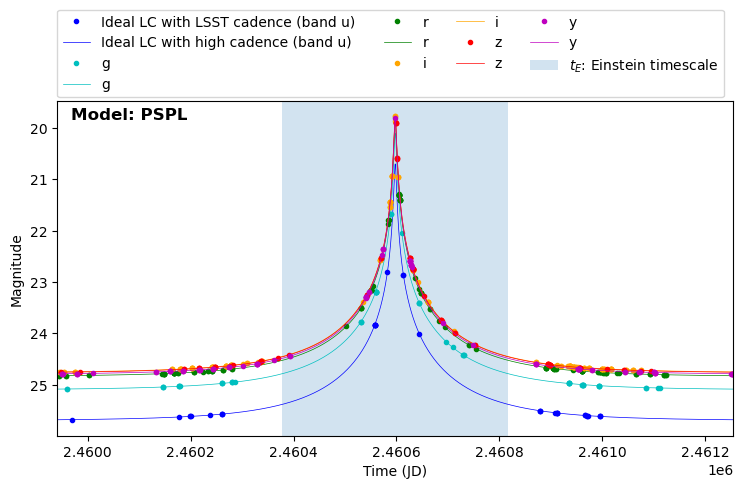

OrderedDict([('t0', np.float64(2460597.7320212)),
             ('u0', 0.01),
             ('tE', np.float64(219.1925636041397)),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('fblend_u', 0.0),
             ('gblend_u', 0.0),
             ('fblend_g', 0.0),
             ('gblend_g', 0.0),
             ('fblend_r', 0.0),
             ('gblend_r', 0.0),
             ('fblend_i', 0.0),
             ('gblend_i', 0.0),
             ('fblend_z', 0.0),
             ('gb

In [38]:
params_pspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: PSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

#### Finite Source Point Lens
Generates two light curves using pyLIMA for each band (now for a finite source):
- one with dense cadence (`epochs_ideal`)
- one with the (DP0) LSST cadence (`epochs_jd`)

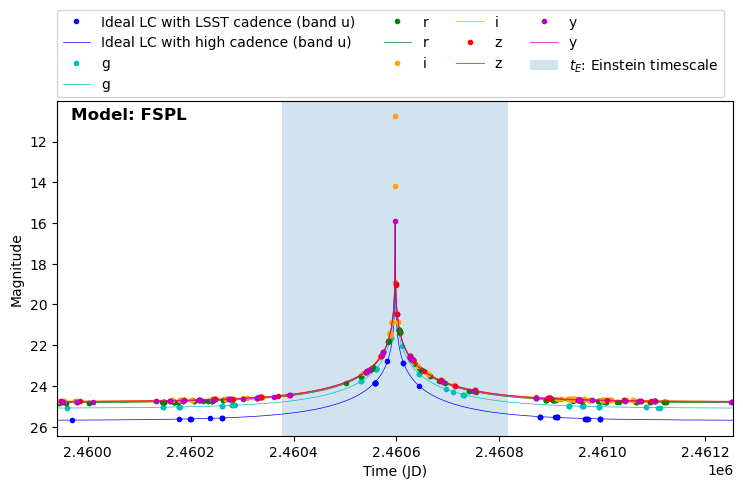

OrderedDict([('t0', np.float64(2460597.7320212)),
             ('u0', np.float64(4.941909334620559e-08)),
             ('tE', np.float64(219.1925636041397)),
             ('rho', np.float64(4.941909334620559e-06)),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('fblend_u', 0.0),
             ('gblend_u', 0.0),
             ('fblend_g', 0.0),
             ('gblend_g', 0.0),
             ('fblend_r', 0.0),
             ('gblend_r', 0.0),
             ('fblend_i', 0

In [39]:
theta_E = einstein_angular_radius(M_L, D_L, D_S)  # mas
tE = einstein_timescale(theta_E, mu_rel)      # days

rho     = norm_source_radius(logL, logTe, D_L, D_S, M_L)
u0      = rho * 0.01                               

params_fspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E,
    "rho": rho
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_fspl, model_type='FSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_fspl, model_type='FSPL', parallax=False
)


plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: FSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

#### Binary system

s=np.float64(1.440370153734264)
q=0.5
alpha=1.7241484721289566


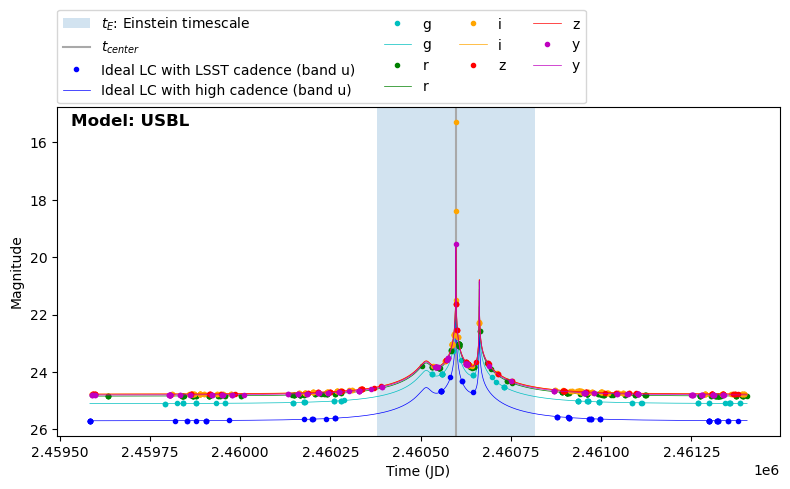

OrderedDict([('t_center', np.float64(2460597.7320212)),
             ('u_center', np.float64(4.941909334620559e-08)),
             ('tE', np.float64(219.1925636041397)),
             ('rho', np.float64(4.941909334620559e-06)),
             ('separation', np.float64(1.440370153734264)),
             ('mass_ratio', 0.5),
             ('alpha', 1.7241484721289566),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('t0', 2460610.726684245),
             ('u0', -0.383553

In [40]:
#semi_major_axis = np.random.uniform(0.1, 28) 
semi_major_axis = 10 
s = norm_separation(D_L, semi_major_axis, theta_E)
print(f"{s=}")
#M_L2 = 0.00095  # approx a planet with Jupyter mass in solar units
M_L2 = M_L/2  # another star with half mass
q = M_L2/M_L
print(f"{q=}")
alpha = np.random.uniform(0, np.pi)
print(f"{alpha=}")

params_usbl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E,
    "rho": rho,
    's': s,          # Normalized separation
    'q': q,          # Mass ratio
    'alpha': alpha   # Trajectory angle (radians)

}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_usbl, model_type='USBL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_usbl, model_type='USBL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: USBL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.axvline(pyLIMA_params["t_center"], color="darkgray", label="$t_{center}$")
#plt.axvline(pyLIMA_params["t0"], color="gray", label="$t_{0}$")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
# plt.xlim(t_0-t_E*3, t_0+t_E*3)

plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

## 5. Complete simulation: Injecting and extracting the ligh-curve on the DP0 images

Now, we will inject each magnitude from pyLIMA in the `calexps` corresponding to the source position for each time-stamp and we will measure the magnitude of the injected source in each image, constructing a light-curve from the images.
To this end, we will use some of the RSP tools.

We will start querying again the sources, and assigning microlensing parameters, as discussed in the beginning of this notebook. However, in this example we will end up simulating only one event.

In [41]:
ra, dec = 62, -34.5
radius = 0.001      # degrees

### Getting sources in the new region
Note: we will end up using only one source

In [42]:
catalog = "lsst_sim.simdr2" # "lsst_sim.simdr2_binary"
columns = ["ra", "dec", "logl", "logte", 
           "umag", "gmag", "rmag", "imag", "zmag", "ymag", "gc", "label"]
region = (ra, dec, 0.002)
query = sky_catalog_query(catalog, columns, region,  language="sql")
print(query)
try:
    res = qc.query(sql=query, fmt="table")
    sources = res.to_pandas()
except Exception as e:
    print(str(e))



    SELECT ra, dec, logl, logte, umag, gmag, rmag, imag, zmag, ymag, gc, label
    FROM lsst_sim.simdr2
    WHERE q3c_radial_query(ra, dec, 62, -34.5, 0.002)
    


In [43]:
sources

,ra,dec,logl,logte,umag,gmag,rmag,imag,zmag,ymag,gc,label
0,62.000046,-34.500609,-0.495,3.7365,23.557,22.428,21.945,21.768,21.707,21.681,3,1


In [44]:
# recall the event parameters generated from genulens
ulens_systems.head()

,M_L,D_L,D_S,mu_rel
0,0.654286,3490,5443,3.368060
1,0.202545,4581,7715,6.920123
2,0.063387,2758,6055,9.626590
3,0.638739,6834,7359,6.344430
4,0.187773,7332,7353,9.804669


### Load exposures overlapping the chose region
As before, we load the information of the `calexps` and then get the MJD and merge the information.

In [45]:
delta_radius = 0.2  # degrees 
circle = Region.from_ivoa_pos(f"CIRCLE {ra} {dec} {radius}")

n_max = None
datasetRefs = list(
    butler.query_datasets(
        "calexp",
        where=f"visit_detector_region.region OVERLAPS my_region AND band IN {bands_str}",
        bind={"ra": ra, "dec": dec, "my_region": circle},
        limit=None if n_max is None else n_max,
    )
)
print(f"Found {len(datasetRefs)} calexps.")

calexps_data = []
catalog = "CcdVisit"
columns = ["ra", "decl", "expMidptMJD", "detector", "visitId", "psfSigma", "zeroPoint"]
full_catalog = f"dp02_dc2_catalogs.{catalog}"

query = f"""
SELECT {', '.join(columns)}
FROM {full_catalog}
WHERE CONTAINS(
        POINT('ICRS', ra, decl),
        CIRCLE('ICRS', {ra}, {dec}, {radius + delta_radius})
      ) = 1
"""

service = get_tap_service("tap")
job = service.submit_job(query)
job.run()
job.wait(phases=["COMPLETED", "ERROR"])

if job.phase == "ERROR":
    job.raise_if_error()

ccd_visit = job.fetch_result().to_table().to_pandas()

print(f"CCdVisit records found: {len(ccd_visit)}")
calexps_data = []
for ref in datasetRefs:
    detector = ref.dataId["detector"]
    visit = ref.dataId["visit"]
    mask = (ccd_visit["detector"] == detector) & (ccd_visit["visitId"] == visit)
    if mask.any():
        row = ccd_visit[mask].iloc[0]
        data = {
            "detector": detector,
            "visit": visit,
            "band": ref.dataId["band"],
            "expMidptMJD": row["expMidptMJD"],
            "psfSigma": row["psfSigma"],
        }
        calexps_data.append(data)

calexps_data = pd.DataFrame(calexps_data).sort_values("expMidptMJD")
print('We keep only the calexps that overlap with the chosen region:', len(calexps_data))

Found 535 calexps.
CCdVisit records found: 1067
We keep only the calexps that overlap with the chosen region: 535


As before, we split the MJD in the corresponding bands and convert to JD. We also define a high cadence time-stamps, to compare the simulated sample with the ideal (model) one

In [46]:
epochs_mjd = {
    band: sorted(set(calexps_data[calexps_data["band"] == band]["expMidptMJD"].values))
    for band in bands
}
epochs_mjd =  {k: v for k, v in epochs_mjd.items() if len(v) != 0} # clean from empty bands
epoch_idx = {                                           # to easily find the magnitudes after simulation
    b: {m: i for i, m in enumerate(epochs_mjd[b])}
    for b in bands
}
epochs_jd = {band: np.array(epochs_mjd[band])+2400000.5 for band in epochs_mjd}
survey_dates = (min(min(v) for v in epochs_jd.values()), max(max(v) for v in epochs_jd.values()) )
epochs_ideal = {band: np.linspace(survey_dates[0], survey_dates[1], 10000) for band in bands}

### Simulate ideal light curve with LSST cadence

In [47]:
# read and generate parameters
src = sources.iloc[0]
ra = float(src["ra"])
dec = float(src["dec"])
logL = float(src["logl"])
logTe = float(src["logte"])

mags = {
    "u": float(src["umag"]),
    "g": float(src["gmag"]),
    "r": float(src["rmag"]),
    "i": float(src["imag"]),
    "z": float(src["zmag"]),
    "y": float(src["ymag"]),
}

lens = ulens_systems.iloc[3213]
M_L = float(lens["M_L"])     # Msun
D_L = float(lens["D_L"])     # pc
D_S = float(lens["D_S"])     # pc
mu_rel = float(lens["mu_rel"])  # mas/yr

event_id = 0
g = 0.0  # No blending since it comes naturally from image-based simulation
theta_E = einstein_angular_radius(M_L, D_L, D_S)   # mas
t_E     = einstein_timescale(theta_E, mu_rel)      # days
t_0     = np.percentile(epochs_jd["i"], 10)
u0      =  0.1

print("Microlensing Parameters")
print("-" * 40)
print(f"Einstein radius       θ_E  = {theta_E:>10.4f} mas")
print(f"Einstein timescale    t_E  = {t_E:>10.4f} days")
print(f"Event time            t_0  = {t_0:>10.4f} JD")
print(f"Impact parameter      u₀   = {u0:>10}")
print("-" * 40)


Microlensing Parameters
----------------------------------------
Einstein radius       θ_E  =     2.1950 mas
Einstein timescale    t_E  =   219.1926 days
Event time            t_0  = 2459887.6733 JD
Impact parameter      u₀   =        0.1
----------------------------------------


### Generate the light curves at both the LSST/DP0 cadence and the high-cadence

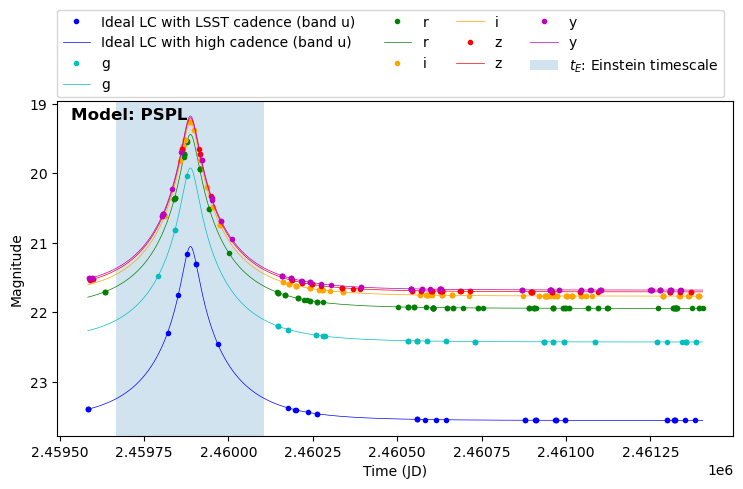

In [48]:
params_pspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: PSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
#plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()


### Loop over exposures to inject sources

Set up configuration of tasks

In [49]:
from lsst.source.injection import VisitInjectConfig, VisitInjectTask
from astropy.table import Table


inject_config = VisitInjectConfig(process_all_data_ids=True)
injection_task = VisitInjectTask(config=inject_config)

import lsst.afw.table as afwTable
from lsst.meas.base import ForcedMeasurementTask

schema = afwTable.SourceTable.makeMinimalSchema()
alias = schema.getAliasMap() 
x_key = schema.addField("centroid_x", type="D")
y_key = schema.addField("centroid_y", type="D")
alias.set("slot_Centroid", "centroid")

xx_key = schema.addField("shape_xx", type="D")
yy_key = schema.addField("shape_yy", type="D")
xy_key = schema.addField("shape_xy", type="D")
alias.set("slot_Shape", "shape")
type_key = schema.addField("type_flag", type="F")
config = ForcedMeasurementTask.ConfigClass()
config.copyColumns = {}
config.plugins.names = [
    "base_TransformedCentroid",
    "base_PsfFlux",
    "base_TransformedShape"
]
config.doReplaceWithNoise = False
forcedMeasurementTask = ForcedMeasurementTask(schema, config=config)
del config

def pix_to_sky(exposure, x, y):
    """Convert pixel coordinates to RA and Dec."""
    sphere_point = exposure.wcs.pixelToSky(geom.Point2D(x, y))
    return sphere_point.getRa().asDegrees(), sphere_point.getDec().asDegrees()

def sky_to_pix(exposure, ra, dec):
    """Convert RA and Dec to pixel coordinates."""
    xy = exposure.wcs.skyToPixel(geom.SpherePoint(ra * geom.degrees, dec * geom.degrees))
    return int(np.round(xy.getX())), int(np.round(xy.getY()))

def flux_to_mag(exposure, flux, flux_err):
    photoCalib = exposure.getPhotoCalib()
    measure = photoCalib.instFluxToMagnitude(flux, flux_err)
    return measure.value, measure.error

Inject and extract magnitudes to build the light curve from this process. Run on the first 40 calexps as an illustration, to save time

In [61]:
import lsst.geom as geom 

n_points = 1
n_calexps = 40
ra_values, dec_values = [ra], [dec]
datasetType = 'calexp'

photometry = pd.DataFrame({
    "overlap": pd.Series(dtype=bool),
    "timeMJD": pd.Series(dtype=float),
    "band": pd.Series(dtype=str),
    "meas_mag": pd.Series(dtype=float),
    "meas_mag_err": pd.Series(dtype=float),
    "meas_flux": pd.Series(dtype=float),
    "meas_flux_err": pd.Series(dtype=float),
    "injected_mag": pd.Series(dtype=float),
    "injection_flag": pd.Series(dtype=float),
    "measure_flag": pd.Series(dtype=float),
})


for i, (idx, calexp_data) in enumerate(calexps_data.head(n_calexps).iterrows()):
    print(f" ----------- Calexp {i+1} ----------- ")
    calexp_photo = {}
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get(datasetType, dataId=dataId)
    band = calexp_data["band"]
    mjd  = calexp_data["expMidptMJD"]
    idx_ep = epoch_idx[band][mjd]
    mag = magnitudes[band][idx_ep]

    calexp_photo["timeMJD"] = mjd
    calexp_photo["band"] = band
    calexp_photo["injected_mag"] = mag

    calexp_photo["meas_mag"] = np.nan
    calexp_photo["meas_mag_err"] = np.nan
    calexp_photo["meas_flux"] = np.nan
    calexp_photo["meas_flux_err"] = np.nan
    calexp_photo["injection_flag"] = np.nan
    calexp_photo["measure_flag"] = np.nan   
    calexp_photo["overlap"] = calexp.containsSkyCoords(ra*u.deg, dec*u.deg)[0]
    if calexp_photo["overlap"]:
        # Inject
        injection_id = list(range(n_points))
        source_type = ["Star"] * n_points
        data = [injection_id, ra_values, dec_values, source_type, [mag]]
        inject_table = Table(data, names=['injection_id', 'ra', 'dec', 'source_type', 'mag'])

        injected_output = injection_task.run(
            injection_catalogs=[inject_table],
            input_exposure=calexp.clone(),
            psf=calexp.getPsf(),
            photo_calib=calexp.getPhotoCalib(),
            wcs=calexp.wcs
        )

        injected_exposure = injected_output.output_exposure
        injected_catalog = injected_output.output_catalog
        calexp_photo["injection_flag"] = injected_catalog["injection_flag"][0]

            
        if len(injected_catalog) > 0:
            
            # Forced Measurement
            forcedSource = afwTable.SourceCatalog(schema)
            for source in injected_catalog:
                sourceRec = forcedSource.addNew()
                coord = geom.SpherePoint(geom.Angle(source["ra"], geom.degrees).asRadians(),geom.Angle(source["dec"], geom.degrees).asRadians(), geom.radians)
                sourceRec.setCoord(coord)
                sourceRec[x_key], sourceRec[y_key]= sky_to_pix(injected_exposure, source["ra"], source["dec"])
                sourceRec[type_key] = 0
            del sourceRec, coord
            forcedMeasCat = forcedMeasurementTask.generateMeasCat(
                injected_exposure, forcedSource, injected_exposure.getWcs()
            )
            forcedMeasurementTask.run(
                forcedMeasCat, injected_exposure, forcedSource, injected_exposure.getWcs()
            )

            # Transform flux to mag 
            tab = forcedMeasCat.asAstropy()
            flux     = tab["base_PsfFlux_instFlux"].value
            flux_err = tab["base_PsfFlux_instFluxErr"].value
            m, m_err = zip(*(flux_to_mag(injected_exposure, f, e) for f, e in zip(flux, flux_err)))

            # Save
            calexp_photo["meas_mag"] = m[0]
            calexp_photo["meas_mag_err"] = m_err[0]
            calexp_photo["meas_flux"] = flux[0]
            calexp_photo["meas_flux_err"] = flux_err[0]
            calexp_photo["measure_flag"] = 1 if tab["base_PsfFlux_flag"][0] else 0


    photometry = pd.concat([photometry, pd.DataFrame([calexp_photo])], ignore_index=True)



 ----------- Calexp 1 ----------- 


 ----------- Calexp 2 ----------- 


 ----------- Calexp 3 ----------- 


 ----------- Calexp 4 ----------- 
 ----------- Calexp 5 ----------- 


 ----------- Calexp 6 ----------- 
 ----------- Calexp 7 ----------- 


...

 ----------- Calexp 32 ----------- 


 ----------- Calexp 33 ----------- 


 ----------- Calexp 34 ----------- 


 ----------- Calexp 35 ----------- 
 ----------- Calexp 36 ----------- 
 ----------- Calexp 37 ----------- 
 ----------- Calexp 38 ----------- 
 ----------- Calexp 39 ----------- 


 ----------- Calexp 40 ----------- 


In [63]:
photometry

,overlap,timeMJD,band,meas_mag,meas_mag_err,meas_flux,meas_flux_err,injected_mag,injection_flag,measure_flag
0,True,59583.120963,u,23.514782,0.160458,608.998755,90.002388,23.394686,0.0,0.0
1,True,59583.122790,u,23.468020,0.157315,636.912450,92.283691,23.394684,0.0,0.0
2,True,59583.126910,u,23.365418,0.149139,699.992522,96.152152,23.394679,0.0,0.0
3,False,59588.091815,y,NaN,NaN,NaN,NaN,21.512504,NaN,NaN
4,True,59588.093238,y,21.518944,0.160133,4376.449082,645.472846,21.512502,0.0,0.0
5,False,59591.081810,z,NaN,NaN,NaN,NaN,21.534655,NaN,NaN
6,True,59591.081810,z,21.530069,0.060104,9402.072870,520.475910,21.534655,0.0,0.0
7,True,59591.096205,z,21.586438,0.062615,8914.489758,514.101196,21.534636,0.0,0.0
8,True,59597.083306,y,21.460146,0.166802,4608.618554,708.022352,21.500622,0.0,0.0
9,True,59597.089947,y,21.514317,0.167178,4409.124608,678.901376,21.500613,0.0,0.0


Plotting the light-curve

(59492.069153, 59941.3304822)

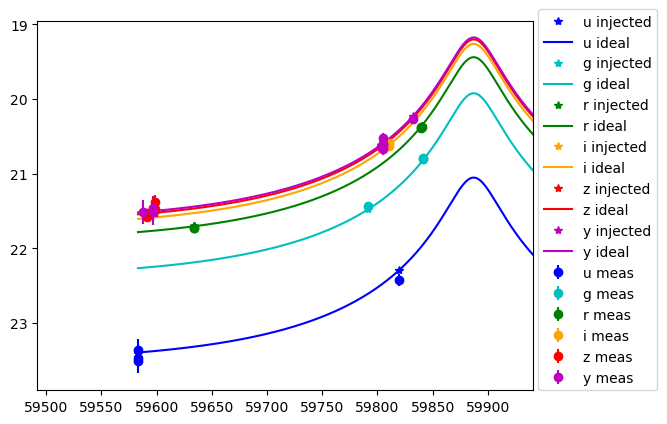

In [64]:
for band in bands:
    phot_band = photometry[photometry["band"]==band]
    plt.errorbar(phot_band["timeMJD"], phot_band["meas_mag"], yerr=abs(phot_band["meas_mag_err"]), 
                 marker="o", linestyle="", color = COLOR_FILTER[band], label = f"{band} meas")
    plt.plot(phot_band["timeMJD"], phot_band["injected_mag"], "*", color = COLOR_FILTER[band], label = f"{band} injected")
    plt.plot(np.array(epochs_ideal[band])-2400000.5, magnitudes_ideal[band], color = COLOR_FILTER[band], label = f"{band} ideal")
    
    # plt.plot(epochs_mjd[band], 
plt.gca().invert_yaxis()
plt.legend(loc=(1.01,0))
plt.xlim(None, max(photometry["timeMJD"])+100)

Now running for all calexps (warning, this will take about 45 minutes)

In [65]:
n_points = 1
n_calexps = None 
ra_values, dec_values = [ra], [dec]
datasetType = 'calexp'

photometry = pd.DataFrame({
    "overlap": pd.Series(dtype=bool),
    "timeMJD": pd.Series(dtype=float),
    "band": pd.Series(dtype=str),
    "meas_mag": pd.Series(dtype=float),
    "meas_mag_err": pd.Series(dtype=float),
    "meas_flux": pd.Series(dtype=float),
    "meas_flux_err": pd.Series(dtype=float),
    "injected_mag": pd.Series(dtype=float),
    "injection_flag": pd.Series(dtype=float),
    "measure_flag": pd.Series(dtype=float),
})


for i, (idx, calexp_data) in enumerate(calexps_data.head(n_calexps).iterrows()):
    print(f" ----------- Calexp {i+1} ----------- ")
    calexp_photo = {}
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get(datasetType, dataId=dataId)
    band = calexp_data["band"]
    mjd  = calexp_data["expMidptMJD"]
    idx_ep = epoch_idx[band][mjd]
    mag = magnitudes[band][idx_ep]

    calexp_photo["timeMJD"] = mjd
    calexp_photo["band"] = band
    calexp_photo["injected_mag"] = mag

    calexp_photo["meas_mag"] = np.nan
    calexp_photo["meas_mag_err"] = np.nan
    calexp_photo["meas_flux"] = np.nan
    calexp_photo["meas_flux_err"] = np.nan
    calexp_photo["injection_flag"] = np.nan
    calexp_photo["measure_flag"] = np.nan   
    calexp_photo["overlap"] = calexp.containsSkyCoords(ra*u.deg, dec*u.deg)[0]
    if calexp_photo["overlap"]:
        # Inject
        injection_id = list(range(n_points))
        source_type = ["Star"] * n_points
        data = [injection_id, ra_values, dec_values, source_type, [mag]]
        inject_table = Table(data, names=['injection_id', 'ra', 'dec', 'source_type', 'mag'])

        injected_output = injection_task.run(
            injection_catalogs=[inject_table],
            input_exposure=calexp.clone(),
            psf=calexp.getPsf(),
            photo_calib=calexp.getPhotoCalib(),
            wcs=calexp.wcs
        )

        injected_exposure = injected_output.output_exposure
        injected_catalog = injected_output.output_catalog
        calexp_photo["injection_flag"] = injected_catalog["injection_flag"][0]

            
        if len(injected_catalog) > 0:
            
            # Forced Measurement
            forcedSource = afwTable.SourceCatalog(schema)
            for source in injected_catalog:
                sourceRec = forcedSource.addNew()
                coord = geom.SpherePoint(geom.Angle(source["ra"], geom.degrees).asRadians(),geom.Angle(source["dec"], geom.degrees).asRadians(), geom.radians)
                sourceRec.setCoord(coord)
                sourceRec[x_key], sourceRec[y_key]= sky_to_pix(injected_exposure, source["ra"], source["dec"])
                sourceRec[type_key] = 0
            del sourceRec, coord
            forcedMeasCat = forcedMeasurementTask.generateMeasCat(
                injected_exposure, forcedSource, injected_exposure.getWcs()
            )
            forcedMeasurementTask.run(
                forcedMeasCat, injected_exposure, forcedSource, injected_exposure.getWcs()
            )

            # Transform flux to mag 
            tab = forcedMeasCat.asAstropy()
            flux     = tab["base_PsfFlux_instFlux"].value
            flux_err = tab["base_PsfFlux_instFluxErr"].value
            m, m_err = zip(*(flux_to_mag(injected_exposure, f, e) for f, e in zip(flux, flux_err)))

            # Save
            calexp_photo["meas_mag"] = m[0]
            calexp_photo["meas_mag_err"] = m_err[0]
            calexp_photo["meas_flux"] = flux[0]
            calexp_photo["meas_flux_err"] = flux_err[0]
            calexp_photo["measure_flag"] = 1 if tab["base_PsfFlux_flag"][0] else 0


    photometry = pd.concat([photometry, pd.DataFrame([calexp_photo])], ignore_index=True)

 ----------- Calexp 1 ----------- 


 ----------- Calexp 2 ----------- 


 ----------- Calexp 3 ----------- 


 ----------- Calexp 4 ----------- 
 ----------- Calexp 5 ----------- 


 ----------- Calexp 6 ----------- 
 ----------- Calexp 7 ----------- 


...

 ----------- Calexp 526 ----------- 
 ----------- Calexp 527 ----------- 
 ----------- Calexp 528 ----------- 


 ----------- Calexp 529 ----------- 
 ----------- Calexp 530 ----------- 
 ----------- Calexp 531 ----------- 
 ----------- Calexp 532 ----------- 


 ----------- Calexp 533 ----------- 


 ----------- Calexp 534 ----------- 


 ----------- Calexp 535 ----------- 


(59492.069153, 61504.1571672)

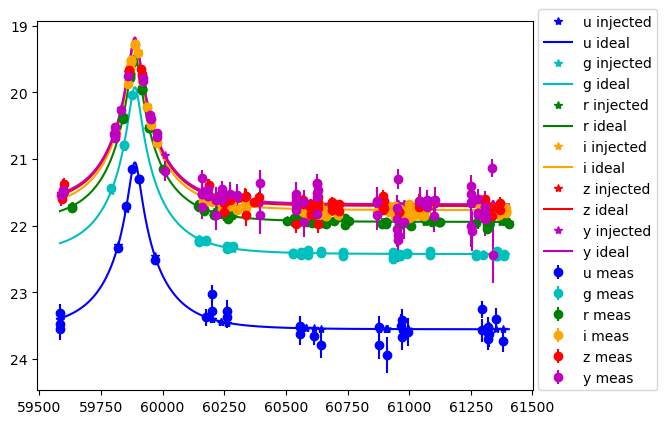

In [66]:
# plotting
for band in bands:
    phot_band = photometry[photometry["band"]==band]
    plt.errorbar(phot_band["timeMJD"], phot_band["meas_mag"], yerr=abs(phot_band["meas_mag_err"]), 
                 marker="o", linestyle="", color = COLOR_FILTER[band], label = f"{band} meas")
    plt.plot(phot_band["timeMJD"], phot_band["injected_mag"], "*", color = COLOR_FILTER[band], label = f"{band} injected")
    plt.plot(np.array(epochs_ideal[band])-2400000.5, magnitudes_ideal[band], color = COLOR_FILTER[band], label = f"{band} ideal")
    
    # plt.plot(epochs_mjd[band], 
plt.gca().invert_yaxis()
plt.legend(loc=(1.01,0))
plt.xlim(None, max(photometry["timeMJD"])+100)

# ulens_lsst: A pipeline to simulate LSST-like light curves at image-level

The `ulens_lsst` pipeline performs all the tasks discussed in this notebook in an automated way. The user selects the type of microlensing system, the number of microlensing events to be generated, the region where the events will be injected and it generates the simulated light-curves, outputing a catalog with all information from the events and from the extraction. The pipeline runs much faster per light curve than this notebooks, as multiple light curves are injected at the same time and the code is parallelized. The code can be used to produce massive simulations of microlensing light curves on DP0 and DP1.

The code is accessible at: https://github.com/nowokaren/ulens_lsst 

Installation:

```
git clone https://github.com/nowokaren/ulens_lsst.git
cd ulens_lsst
pip install -e .
```
 

In [1]:
from ulens_lsst.simulation_pipeline import SimPipeline 

CONFIG_PATH = "config_file.yaml"
sim = SimPipeline(CONFIG_PATH)

results_events = sim.simulate_lightcurves()
results_events

Loading AstroDataLab sources from lsst_sim.simdr2:   0%|          | 0/20 [00:00<?, ?it/s]

Found 999 calexps.
Loading data from dp02_dc2_catalogs.CcdVisit...
Records found: 5256


Running parallel processing: 100%|██████████| 10/10 [00:09<00:00,  1.04it/s]


runs/new_test/temp


,event_id,status,error
0,0,success,
1,1,success,
2,14,success,
3,15,success,
4,12,success,
5,13,success,
6,8,success,
7,9,success,
8,4,success,
9,5,success,


In [2]:
sim.load_nearby_objects()
results_calexps = sim.process_synthetic_photometry()

results_calexps

Loading data from dp02_dc2_catalogs.Object...
Records found: 6639


Running parallel processing: 100%|██████████| 8/8 [11:11<00:00, 83.95s/it]


,calexp_id,status,error
0,250,success,
1,251,failed,No sources to inject: skipping this calexp
2,252,success,
3,253,success,
4,254,success,
...,...,...,...
994,994,success,
995,995,success,
996,996,success,
997,997,success,


<Axes: title={'center': 'Event 8'}, xlabel='Time (MJD)', ylabel='Magnitude'>

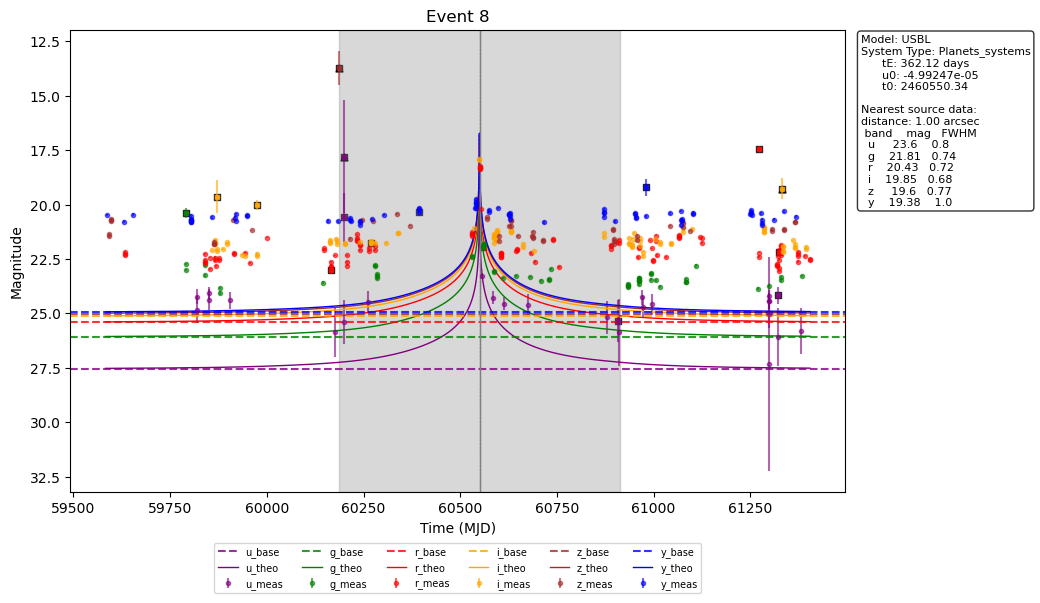

In [3]:
from ulens_lsst.light_curves import Event

event = Event.from_parquet(8, sim.calexps_photometry_file, sim.events_file)

event.plot(show_ideal=False, simulate_ideal=True)

In [4]:
event.parameters

{'u': np.float64(27.553),
 'g': np.float64(26.088),
 'r': np.float64(25.416),
 'i': np.float64(25.139),
 'z': np.float64(25.017),
 'y': np.float64(24.953),
 't0': np.float64(2460550.337980691),
 'tE': np.float64(362.11541007659207),
 'u0': np.float64(-4.992474590583444e-05),
 'radius': np.float64(0.46329025036876254),
 'q': np.float64(0.00011133635703813517),
 'rho': np.float64(3.1132334082898044e-05),
 's': np.float64(0.6298531319879161),
 'alpha': np.float64(0.035810399777681676),
 'piEE': np.float64(-0.010230876436543959),
 'piEN': np.float64(0.004777525838908064),
 'f_blend': np.float64(0.0)}

In [5]:
event.pylima_parameters

{'t_center': np.float64(2460550.337980691),
 'u_center': np.float64(-4.992474590583444e-05),
 'tE': np.float64(362.11541007659207),
 'rho': np.float64(3.1132334082898044e-05),
 'separation': np.float64(0.6298531319879161),
 'mass_ratio': np.float64(0.00011133635703813517),
 'alpha': np.float64(0.035810399777681676),
 'piEN': np.float64(0.004777525838908064),
 'piEE': np.float64(-0.010230876436543959),
 'fsource_u': np.float64(0.6177318585915202),
 'ftotal_u': np.float64(0.6177318585915202),
 'fblend_u': np.float64(0.0),
 'gblend_u': np.float64(0.0),
 'fsource_g': np.float64(8.256576326213251),
 'ftotal_g': np.float64(8.256576326213251),
 'fblend_g': np.float64(0.0),
 'gblend_g': np.float64(0.0),
 'fsource_r': np.float64(12.519875206248813),
 'ftotal_r': np.float64(12.519875206248813),
 'fblend_r': np.float64(0.0),
 'gblend_r': np.float64(0.0),
 'fsource_i': np.float64(12.145069377157816),
 'ftotal_i': np.float64(12.145069377157816),
 'fblend_i': np.float64(0.0),
 'gblend_i': np.float64

Event 8 - Plotting filter light curves:   0%|          | 0/6 [00:00<?, ?it/s]

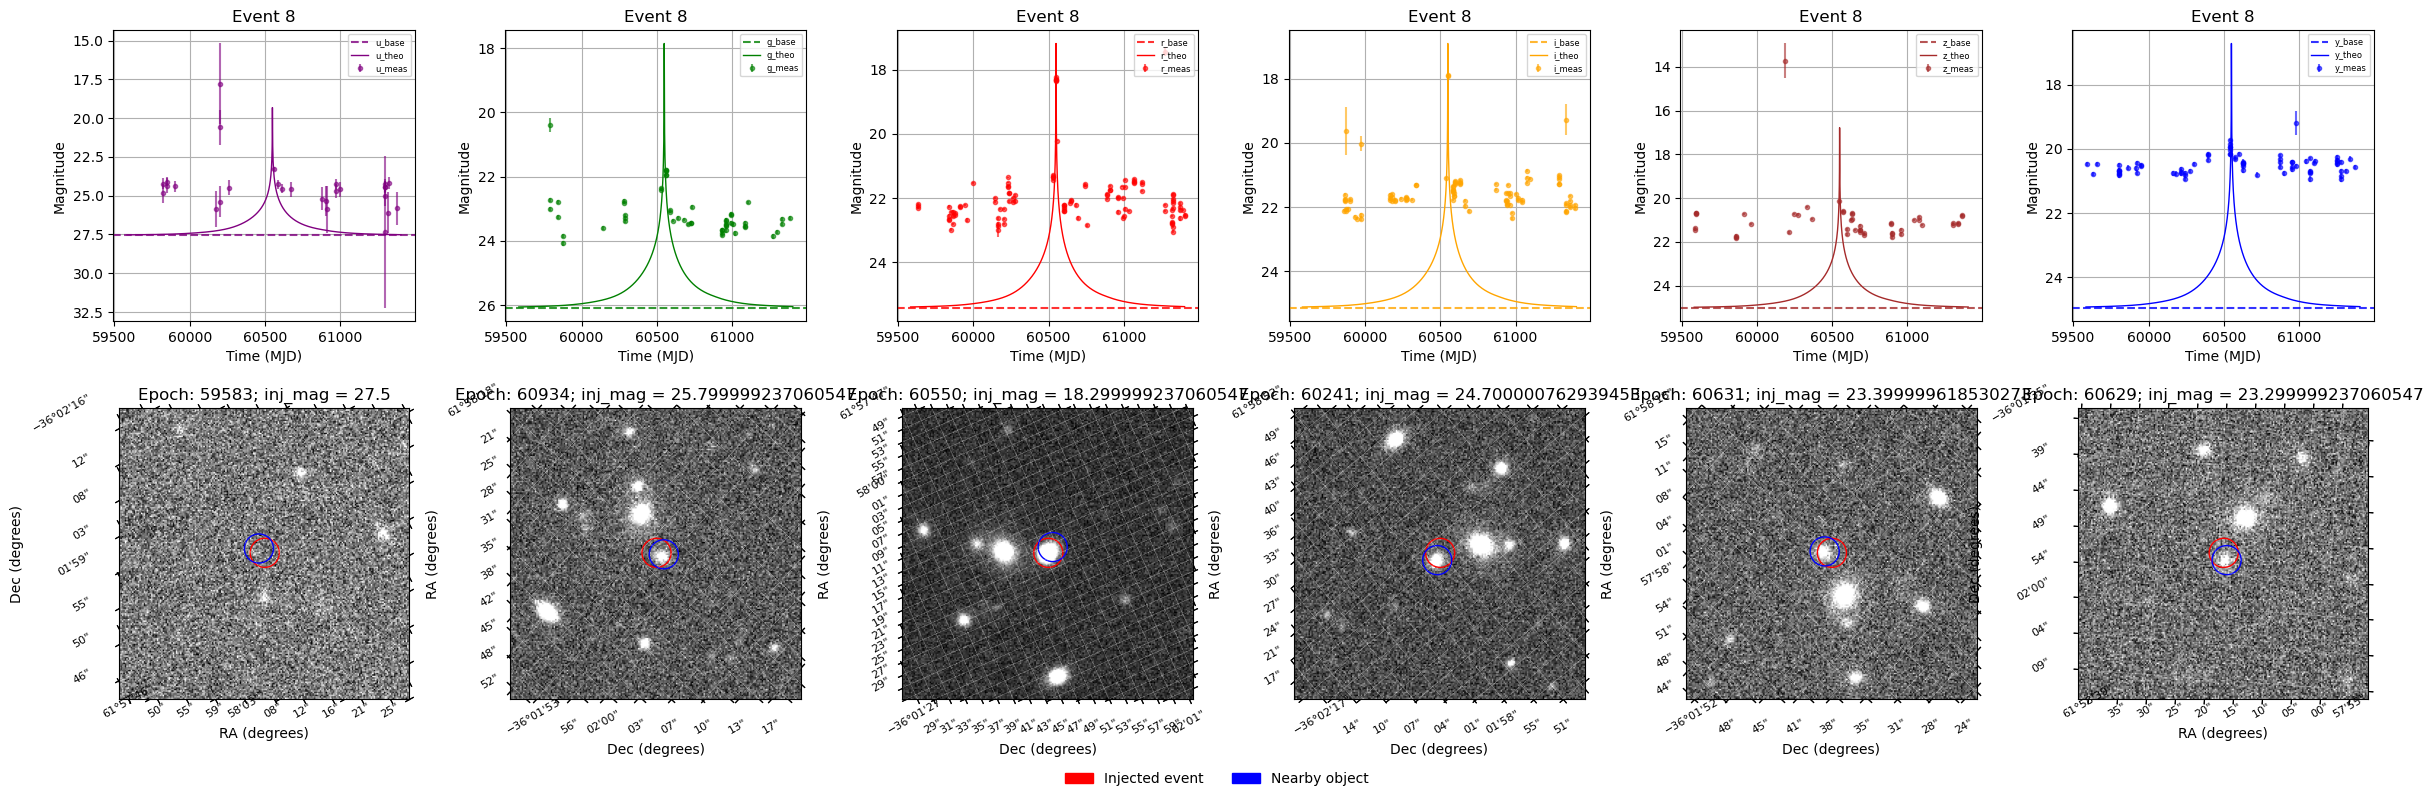

In [7]:
from ulens_lsst.analysis import plot_event_fov
plot_event_fov(8, sim.name, save=False)

<Axes: title={'center': 'Event 17'}, xlabel='Time (MJD)', ylabel='Magnitude'>

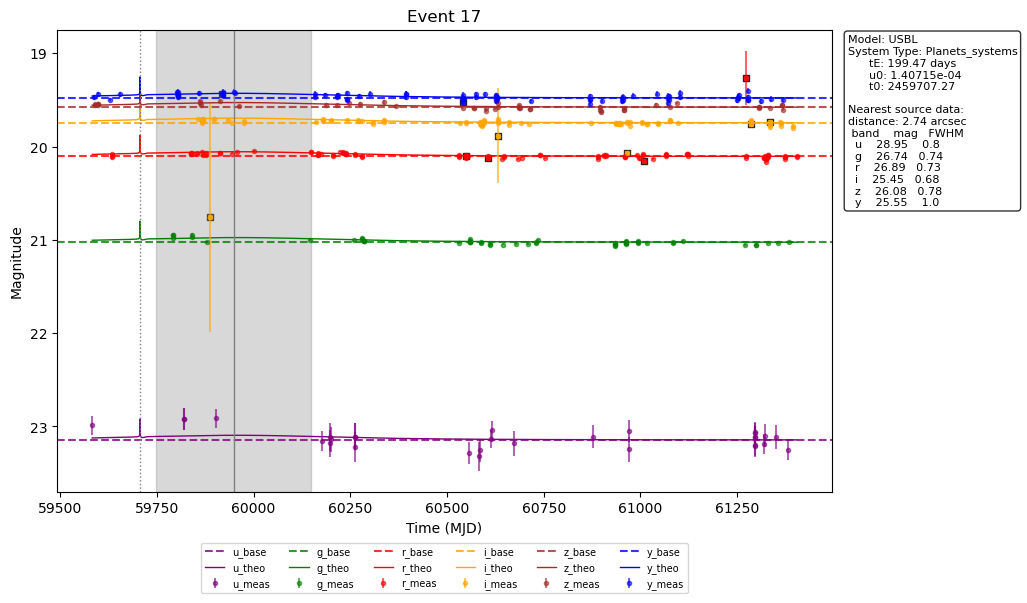

In [10]:
from ulens_lsst.light_curves import Event
event = Event.from_parquet(17, sim.calexps_photometry_file, sim.events_file)
event.plot(show_ideal=False, simulate_ideal=True)

<Axes: title={'center': 'Event 2'}, xlabel='Time (MJD)', ylabel='Magnitude'>

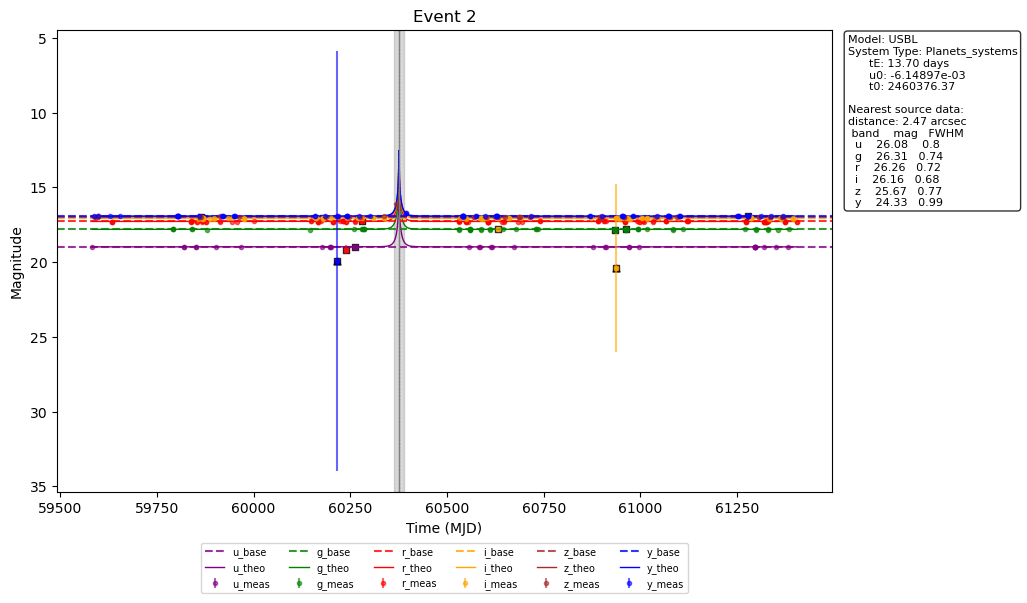

In [12]:
from ulens_lsst.light_curves import Event
event = Event.from_parquet(2, sim.calexps_photometry_file, sim.events_file)
event.plot(show_ideal=False, simulate_ideal=True)